# Build a Tiny LLM From Scratch 

This project builds a small, working GPT-style language model, using only
torch tensor operations for the core math (no nn.TransformerEncoder, no nn.MultiheadAttention).



In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cpu


## 1. What is a Language Model?

A **Language Model (LM)** is a system that predicts the next token given a sequence of
previous tokens:

$$P(x_t \mid x_1, x_2, \dots, x_{t-1})$$

A **Large Language Model (LLM)** is s a system that predicts the next token given a sequence of
previous tokensbut for more parameters, more data, more
computation.



## 2. Tokens & Tokenization

**Token** is a basic unit of text an LLM operates on. It is not always a word, it can be a
character, a sub-word piece, or a whole word, depending on the tokenizer.

- Real LLMs such as GPT-4, Llama, etc, use **Byte Pair Encoding (BPE)** or similar sub-word schemes, which
  balance vocabulary size against sequence length by merging frequently co-occurring character pairs.
- For this project we use the simplest possible tokenizer i.e **character-level** , so we can verify
  every step without a large vocabulary getting in the way. The concepts suchas embedding lookup, attention,
  etc are identical regardless of tokenizer granularity.

**Tokenization** is the process of converting raw text into a sequence of integer IDs the model can
consume, using a fixed vocabulary.


In [2]:
# A tiny toy corpus to train on
text = (
    "the quick brown fox jumps over the lazy dog. "
    "the dog barks at the fox. the fox runs away quickly. "
    "a quick fox and a lazy dog become friends over time. "
    "the sun rises and the dog wakes up. the fox sleeps all day."
)

# Build the vocabulary: every unique character in the corpus
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(f"Vocabulary ({vocab_size} tokens): {chars}")

# Tokenizer: two lookup tables, char -> id and id -> char
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

def encode(s):
    """string -> list of token ids"""
    return [stoi[c] for c in s]

def decode(ids):
    """list of token ids -> string"""
    return "".join(itos[i] for i in ids)

sample = "the fox"
print(f"'{sample}' -> {encode(sample)}")
print(f"{encode(sample)} -> '{decode(encode(sample))}'")


Vocabulary (28 tokens): [' ', '.', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
'the fox' -> [21, 9, 6, 0, 7, 16, 25]
[21, 9, 6, 0, 7, 16, 25] -> 'the fox'


## 3. Embeddings

Token IDs are just arbitrary integers i.e the number `5` is not "closer" in meaning to `6` than to
`50`. So the model's first job is to convert each token ID into a **dense vector** for e.g. 32 or 4096
numbers,where it can actually learn meaningful relationships over. This lookup table is the
**embedding layer** i.e a matrix of shape (vocab_size, embedding_dim) where row `i` is the vector for
token `i`. These vectors start random and are learned during training, so that tokens used in similar
contexts end up with similar vectors.

### Positional Embeddings
Attention  has no built-in notion of word order as it treats the input as a *set*, not a
*sequence*. So we add a second embedding table that encodes **position** (0, 1, 2, ...) and add it
elementwise to the token embedding as depicted below. This is how the model learns that "dog bites man" differs from
"man bites dog".


In [3]:
embedding_dim = 32
context_length = 16  # max sequence length the model will see at once

token_embedding_table = nn.Embedding(vocab_size, embedding_dim).to(device)
position_embedding_table = nn.Embedding(context_length, embedding_dim).to(device)

# Demo: embed a short token sequence
demo_ids = torch.tensor([encode("the fox")]).to(device)  # shape (1, seq_len)
tok_emb = token_embedding_table(demo_ids)                # (1, seq_len, embedding_dim)
pos_ids = torch.arange(demo_ids.shape[1], device=device)
pos_emb = position_embedding_table(pos_ids)               # (seq_len, embedding_dim)

x = tok_emb + pos_emb  # broadcast add: every position gets its positional vector
print(f"token ids shape:        {demo_ids.shape}")
print(f"token embedding shape:  {tok_emb.shape}")
print(f"position embedding shape: {pos_emb.shape}")
print(f"combined input shape:   {x.shape}")


token ids shape:        torch.Size([1, 7])
token embedding shape:  torch.Size([1, 7, 32])
position embedding shape: torch.Size([7, 32])
combined input shape:   torch.Size([1, 7, 32])


## 4. Self-Attention (the Core Idea)

Self-attention lets each token look at every other token in the sequence and decide "how much to pay
attention to it" when building its own updated representation. For every token we compute three
vectors, learned via linear projections of its embedding:

- **Query (Q)** — "what am I looking for?"
- **Key (K)** — "what do I contain?"
- **Value (V)** — "what do I actually offer if you attend to me?"

Attention scores are the dot product of a token's Query with every token's Key (scaled by
$\sqrt{d_k}$ for numerical stability), turned into a probability distribution with softmax, then used
to take a weighted sum of the Value vectors:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$


In [4]:
class SelfAttentionHead(nn.Module):
    """A single self-attention head, implemented from scratch."""
    def __init__(self, embedding_dim, head_size):
        super().__init__()
        self.query = nn.Linear(embedding_dim, head_size, bias=False)
        self.key   = nn.Linear(embedding_dim, head_size, bias=False)
        self.value = nn.Linear(embedding_dim, head_size, bias=False)
        self.head_size = head_size

    def forward(self, x, causal_mask=None):
        # x: (batch, seq_len, embedding_dim)
        Q = self.query(x)   # (batch, seq_len, head_size)
        K = self.key(x)     # (batch, seq_len, head_size)
        V = self.value(x)   # (batch, seq_len, head_size)

        # scaled dot-product attention scores
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.head_size)  # (batch, seq_len, seq_len)

        if causal_mask is not None:
            scores = scores.masked_fill(causal_mask == 0, float("-inf"))

        weights = F.softmax(scores, dim=-1)  # attention weights: rows sum to 1
        out = weights @ V                     # (batch, seq_len, head_size)
        return out, weights

# Quick sanity check on our 2-token demo sequence
head = SelfAttentionHead(embedding_dim, head_size=8).to(device)
out, weights = head(x)
print(f"attention output shape: {out.shape}")
print(f"attention weights (rows sum to 1):\n{weights[0].detach()}")


attention output shape: torch.Size([1, 7, 8])
attention weights (rows sum to 1):
tensor([[0.0639, 0.0876, 0.7496, 0.0199, 0.0093, 0.0032, 0.0665],
        [0.1058, 0.1316, 0.3477, 0.0996, 0.0625, 0.1001, 0.1527],
        [0.1068, 0.1449, 0.1640, 0.2248, 0.0974, 0.1447, 0.1174],
        [0.1121, 0.2475, 0.1534, 0.0521, 0.1273, 0.1195, 0.1881],
        [0.1445, 0.1681, 0.0915, 0.2716, 0.1497, 0.1025, 0.0721],
        [0.1626, 0.1081, 0.1192, 0.2787, 0.1000, 0.0803, 0.1511],
        [0.2056, 0.0971, 0.0753, 0.2705, 0.0850, 0.1543, 0.1123]])


## 5. Causal Masking

An LLM generates text left-to-right . When predicting token `t`, it must not be allowed to see tokens
`t+1, t+2, ...` because it would be cheating and impossible at generation time, since they don't exist
yet. We enforce this with a **causal mask**: It is a lower-triangular matrix that blocks attention to future
positions by setting their score to $-\infty$ before the softmax, so their attention weight becomes 0.


In [5]:
def make_causal_mask(seq_len, device):
    # Lower-triangular matrix of 1s: position i can attend to positions <= i
    return torch.tril(torch.ones(seq_len, seq_len, device=device))

mask = make_causal_mask(x.shape[1], device)
print("Causal mask (1 = can attend, 0 = blocked):")
print(mask)

out, weights = head(x, causal_mask=mask)
print("\nAttention weights WITH causal masking (upper triangle is now 0):")
print(weights[0].detach())


Causal mask (1 = can attend, 0 = blocked):
tensor([[1., 0., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1., 1.]])

Attention weights WITH causal masking (upper triangle is now 0):
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4456, 0.5544, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2570, 0.3485, 0.3945, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1984, 0.4380, 0.2715, 0.0922, 0.0000, 0.0000, 0.0000],
        [0.1751, 0.2037, 0.1108, 0.3291, 0.1813, 0.0000, 0.0000],
        [0.1916, 0.1274, 0.1404, 0.3283, 0.1178, 0.0946, 0.0000],
        [0.2056, 0.0971, 0.0753, 0.2705, 0.0850, 0.1543, 0.1123]])


## 6. Multi-Head Attention

A single attention head can only learn one type of relationship at a time for e.g. only syntax, or only
long-range topic. **Multi-head attention** runs several attention heads in parallel, each with its own
learned Q/K/V projections into a smaller sub-space, then concatenates their outputs and projects back
to the full embedding dimension. This lets the model attend to different kinds of relationships
simultaneously.


In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embedding_dim, num_heads):
        super().__init__()
        assert embedding_dim % num_heads == 0, "embedding_dim must be divisible by num_heads"
        head_size = embedding_dim // num_heads
        self.heads = nn.ModuleList([
            SelfAttentionHead(embedding_dim, head_size) for _ in range(num_heads)
        ])
        self.projection = nn.Linear(embedding_dim, embedding_dim)

    def forward(self, x, causal_mask=None):
        head_outputs = [h(x, causal_mask)[0] for h in self.heads]  # list of (batch, seq_len, head_size)
        concatenated = torch.cat(head_outputs, dim=-1)              # (batch, seq_len, embedding_dim)
        return self.projection(concatenated)

mha = MultiHeadAttention(embedding_dim, num_heads=4).to(device)
out = mha(x, causal_mask=mask)
print(f"multi-head attention output shape: {out.shape}")


multi-head attention output shape: torch.Size([1, 7, 32])


## 7. Feed-Forward Network, LayerNorm, and Residual Connections

Each transformer block also contains:

- **Feed-Forward Network (FFN)** : It is a small two-layer MLP applied independently to every position,
  giving the model extra capacity to transform the attended representation for e.g as attention mixes
  information across tokens.
- **LayerNorm** :  It normalizes activations to stabilize and speed up training.
- **Residual /skip connections** : Using `x = x + sublayer(x)` instead of `x = sublayer(x)`. This lets
  gradients flow directly through the network during backpropagation, which is essential for training
  deep stacks of layers.


In [7]:
class FeedForward(nn.Module):
    def __init__(self, embedding_dim, hidden_multiplier=4):
        super().__init__()
        hidden_dim = embedding_dim * hidden_multiplier
        self.net = nn.Sequential(
            nn.Linear(embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, embedding_dim),
        )

    def forward(self, x):
        return self.net(x)

ffn = FeedForward(embedding_dim).to(device)
print(f"feed-forward output shape: {ffn(out).shape}")


feed-forward output shape: torch.Size([1, 7, 32])


## 8. The Transformer Block

Combining everything above with residual connections and LayerNorm gives one **transformer block**:


x = x + MultiHeadAttention(LayerNorm(x))
x = x + FeedForward(LayerNorm(x))


(This "pre-norm" ordering i.e normalizing before each sublayer, is what modern LLMs like GPT-2/3 and
Llama use, as it trains more stably than the original "post-norm" transformer.)


In [8]:
class TransformerBlock(nn.Module):
    def __init__(self, embedding_dim, num_heads):
        super().__init__()
        self.ln1 = nn.LayerNorm(embedding_dim)
        self.attention = MultiHeadAttention(embedding_dim, num_heads)
        self.ln2 = nn.LayerNorm(embedding_dim)
        self.ffn = FeedForward(embedding_dim)

    def forward(self, x, causal_mask=None):
        x = x + self.attention(self.ln1(x), causal_mask)
        x = x + self.ffn(self.ln2(x))
        return x

block = TransformerBlock(embedding_dim, num_heads=4).to(device)
print(f"transformer block output shape: {block(x, mask).shape}")


transformer block output shape: torch.Size([1, 7, 32])


## 9. Assembling the Full GPT Model

 We Stack several transformer blocks, add a final LayerNorm, and project back to vocabulary size to get
unnormalized scores over the next-token prediction. This is a minimal but depends on complete GPT-style
architecture.


In [9]:
class GPTModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, context_length, num_heads, num_layers):
        super().__init__()
        self.context_length = context_length
        self.token_embedding_table = nn.Embedding(vocab_size, embedding_dim)
        self.position_embedding_table = nn.Embedding(context_length, embedding_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embedding_dim, num_heads) for _ in range(num_layers)
        ])
        self.ln_final = nn.LayerNorm(embedding_dim)
        self.lm_head = nn.Linear(embedding_dim, vocab_size)  # projects back to vocab-size logits

    def forward(self, idx, targets=None):
        batch_size, seq_len = idx.shape
        tok_emb = self.token_embedding_table(idx)                                   # (B, T, C)
        pos_emb = self.position_embedding_table(torch.arange(seq_len, device=idx.device))  # (T, C)
        x = tok_emb + pos_emb

        causal_mask = make_causal_mask(seq_len, idx.device)
        for block in self.blocks:
            x = block(x, causal_mask)
        x = self.ln_final(x)
        logits = self.lm_head(x)  # (B, T, vocab_size)

        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.view(B * T, V), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None):
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.context_length:]        # crop to context window
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature          # only need the last position's logits

            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = float("-inf")

            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)  # sample instead of always taking argmax
            idx = torch.cat([idx, next_id], dim=1)
        return idx

model = GPTModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
    context_length=context_length,
    num_heads=4,
    num_layers=3,
).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Model created with {num_params:,} parameters")


Model created with 40,220 parameters


## 10. Training on a Toy Dataset

Training an LLM is **next-token prediction** i.e for every position in the training sequence, the target
is simply the next token. We slice our tiny corpus into overlapping ( such as context, target) chunks and
minimize cross-entropy loss with Adam.


In [10]:
# Encode the whole corpus once
data = torch.tensor(encode(text), dtype=torch.long)

def get_batch(data, context_length, batch_size):
    """Randomly sample batch_size chunks of context_length tokens, with targets shifted by 1."""
    max_start = len(data) - context_length - 1
    start_idxs = torch.randint(0, max_start, (batch_size,))
    x = torch.stack([data[i : i + context_length] for i in start_idxs])
    y = torch.stack([data[i + 1 : i + context_length + 1] for i in start_idxs])
    return x.to(device), y.to(device)

xb, yb = get_batch(data, context_length, batch_size=4)
print(f"input batch shape:  {xb.shape}")
print(f"target batch shape: {yb.shape}")
print(f"\nExample: input  = '{decode(xb[0].tolist())}'")
print(f"         target = '{decode(yb[0].tolist())}'  (shifted right by 1 token)")


input batch shape:  torch.Size([4, 16])
target batch shape: torch.Size([4, 16])

Example: input  = 'quick fox and a '
         target = 'uick fox and a l'  (shifted right by 1 token)


In [11]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)
num_steps = 2000
batch_size = 32
train_losses = []

for step in range(num_steps):
    xb, yb = get_batch(data, context_length, batch_size)
    logits, loss = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())
    if step % 200 == 0 or step == num_steps - 1:
        print(f"step {step:4d} | loss {loss.item():.4f}")


step    0 | loss 3.4218


step  200 | loss 0.2039


step  400 | loss 0.1757


step  600 | loss 0.1655


step  800 | loss 0.1596


...

step 1200 | loss 0.1714


step 1400 | loss 0.1578


step 1600 | loss 0.1670


step 1800 | loss 0.1439


step 1999 | loss 0.1467


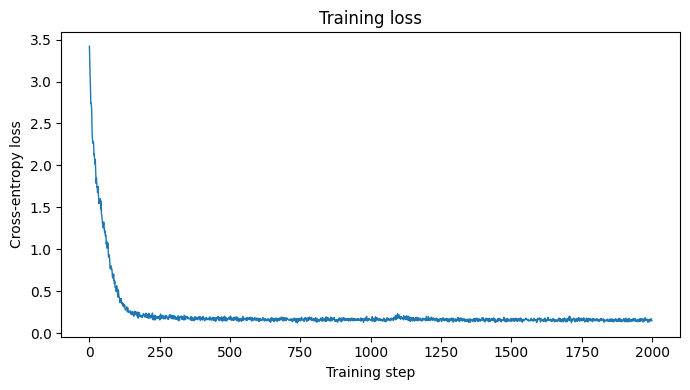

In [12]:
# Plot the training loss curve
fig, ax = plt.subplots(figsize=(7, 4), facecolor="white")
ax.set_facecolor("white")
ax.plot(train_losses, color="tab:blue", linewidth=1)
ax.set_xlabel("Training step")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training loss")
plt.tight_layout()
plt.show()


## 11. Text Generation

At inference time we start from a short prompt and repeatedly run the model, take the logits or unnormalized scores for the
last position, turn them into a probability distribution, and sample the next token. `temperature`
controls randomness (lower = more deterministic, higher = more diverse), and `top_k` restricts sampling
to the k most likely tokens to avoid picking very unlikely ones.


In [13]:
prompt = "the fox"
prompt_ids = torch.tensor([encode(prompt)], device=device)

generated_ids = model.generate(prompt_ids, max_new_tokens=100, temperature=0.8, top_k=10)
print(decode(generated_ids[0].tolist()))


the fox runs away quickly. a quick fox and a lazy dog become friends over time. the sun rises and the dog w


## Notes :

This project is a minimal, from-scratch skeleton of LLMs, but  for real LLMs  we add many refinements on top of exactly
these building blocks. For example:

- **Tokenization**: swap the character-level tokenizer for BPE (e.g. `tiktoken`) or a trained
  SentencePiece/WordPiece model so that sub-word tokenizers give much better coverage and shorter sequences.
- **Positional encoding**: modern models often use **RoPE** (Rotary Position Embeddings) instead of
  learned absolute position embeddings.
- **Normalization**: **RMSNorm** is a common, cheaper alternative to `LayerNorm`.
- **Activation**: **SwiGLU** feed-forward variants outperform plain GELU MLPs at scale.
- **Attention efficiency**: **KV-caching** for fast generation, **Flash Attention** for memory-efficient
  training, **Grouped-Query Attention** to reduce inference memory.
- **Scale**: real LLMs use billions of parameters, trillions of training tokens, and distributed
  training across many GPUs/TPUs.
- **Alignment**: after pretraining (what we did here), production LLMs go through instruction-tuning
  and RLHF/DPO to become helpful, harmless assistants rather than raw text completers.

**References** : Andrej Karpathy's [`nanoGPT`](https://github.com/karpathy/nanoGPT) and the Hugging Face `transformers` library.
